# 03 — Implementación del modelo base con LightGBM

## Detección de fraude en establecimientos de hospedaje

Este notebook corresponde a la **parte 3: Implementación del modelo base**. La idea es entrenar un primer modelo con LightGBM, usando métricas tradicionales como **AUC-ROC** y **F1-score**, y dejar una línea base clara para comparar después las métricas personalizadas enfocadas en reducción de falsos positivos.

**Objetivo del notebook:**

1. Cargar las variables generadas en `02_feature_engineering.ipynb` cuando estén disponibles.
2. Separar entrenamiento histórico y prueba de junio 2025.
3. Entrenar un modelo inicial con LightGBM.
4. Evaluar AUC-ROC, F1-score, fraude detectado y falsos positivos.
5. Guardar resultados base para compararlos contra las métricas custom.

## 1. Importación de librerías y configuración inicial

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report, roc_curve,
    precision_recall_curve
)

RANDOM_STATE = 22
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)

DATA_PROCESSED = Path("../data/processed")
DATA_RAW = Path("../data/raw/01_bo_vip_seed22_n100000.csv")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## 2. Carga de datos

El flujo esperado es usar `train_features.csv` y `test_features_june.csv`, generados por el notebook de ingeniería de variables. Si esos archivos todavía no existen, se carga el dataset raw y se construye una base mínima para que el notebook sea reproducible.

In [2]:
train_path = DATA_PROCESSED / "train_features.csv"
test_path = DATA_PROCESSED / "test_features_june.csv"

if train_path.exists() and test_path.exists():
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    source = "features"
    print("Se cargaron train_features.csv y test_features_june.csv")
else:
    print("No se encontraron archivos processed. Se cargará el CSV raw y se generarán features mínimas.")
    df = pd.read_csv(DATA_RAW, sep=";")

    # Parseo de fecha usado en el EDA: DE7 viene como MMDDHHMMSS sin año explícito.
    df["transaction_datetime"] = pd.to_datetime(
        df["DE7_transmission_datetime"].astype(str).str.zfill(10),
        format="%m%d%H%M%S",
        errors="coerce"
    )
    df["transaction_month"] = df["transaction_datetime"].dt.month
    df["transaction_day"] = df["transaction_datetime"].dt.day

    # Features base alineadas al enfoque de hospedaje.
    df["is_hotel"] = df["DE18_merchant_category_code"].eq(7011)
    df["amount_vs_baseline"] = df["amount_usd"] - df["client_baseline_amount"]
    df["amount_baseline_ratio"] = np.where(
        df["client_baseline_amount"] > 0,
        df["amount_usd"] / df["client_baseline_amount"],
        np.nan
    )
    df["hotel_international"] = df["is_hotel"] & df["is_international"].astype(bool)
    df["hotel_high_distance"] = df["is_hotel"] & (
        df["distance_from_home_km"] > df["distance_from_home_km"].quantile(0.75)
    )

    train_df = df[df["transaction_month"] < 6].copy()
    test_df = df[df["transaction_month"] == 6].copy()
    source = "raw_minimal_features"

print(f"Fuente utilizada: {source}")
print(f"Train: {train_df.shape[0]:,} filas × {train_df.shape[1]} columnas")
print(f"Test junio: {test_df.shape[0]:,} filas × {test_df.shape[1]} columnas")

No se encontraron archivos processed. Se cargará el CSV raw y se generarán features mínimas.


Fuente utilizada: raw_minimal_features
Train: 83,817 filas × 74 columnas
Test junio: 16,186 filas × 74 columnas


## 3. Revisión rápida del balance de clases

Antes de entrenar, se revisa cuántos fraudes hay en entrenamiento y en junio. Esto es importante porque el problema es desbalanceado y una métrica como accuracy puede ser engañosa.

In [3]:
def target_summary(df, name):
    out = df["is_fraud"].value_counts().rename_axis("is_fraud").reset_index(name="count")
    out["percentage"] = out["count"] / len(df) * 100
    out.insert(0, "dataset", name)
    return out

balance = pd.concat([
    target_summary(train_df, "train_meses_1_5"),
    target_summary(test_df, "test_junio")
], ignore_index=True)

balance

,dataset,is_fraud,count,percentage
0,train_meses_1_5,False,79634,95.009366
1,train_meses_1_5,True,4183,4.990634
2,test_junio,False,15450,95.452860
3,test_junio,True,736,4.547140


## 4. Separación temporal para validación

Para no usar junio durante el ajuste, se utiliza una validación temporal: meses 1–4 para entrenamiento interno y mes 5 para validación. Luego, con los hiperparámetros y umbrales definidos, se evalúa sobre junio.

In [4]:
if "transaction_month" in train_df.columns and train_df["transaction_month"].nunique() > 1:
    train_inner = train_df[train_df["transaction_month"] < 5].copy()
    val_df = train_df[train_df["transaction_month"] == 5].copy()
else:
    # Fallback si no existiera la columna temporal: split ordenado 80/20.
    split_idx = int(len(train_df) * 0.80)
    train_inner = train_df.iloc[:split_idx].copy()
    val_df = train_df.iloc[split_idx:].copy()

print(f"Train interno: {train_inner.shape[0]:,} filas")
print(f"Validación:    {val_df.shape[0]:,} filas")
print(f"Test junio:    {test_df.shape[0]:,} filas")

Train interno: 66,644 filas
Validación:    17,173 filas
Test junio:    16,186 filas


## 5. Preparación de variables predictoras

Se eliminan columnas que no deberían alimentar el modelo base por ser identificadores, datos sensibles, variables de respuesta posterior a la autorización o la variable objetivo. Las variables categóricas se codifican de forma consistente entre entrenamiento, validación y prueba.

In [5]:
TARGET = "is_fraud"

# Columnas que pueden introducir fuga de información, identificadores directos o poca generalización.
manual_drop = {
    TARGET,
    "transaction_id", "pan_masked", "pan_hash", "DE2_PAN", "DE35_track2_data_masked",
    "DE37_retrieval_reference_number", "DE38_authorization_code", "DE41_terminal_id",
    "DE42_card_acceptor_id", "DE43_card_acceptor_name_location", "DE102_account_id_1",
    "DE103_account_id_2", "client_home_city", "bank_code", "bank_name", "bank_country", "bank_tier",
    "approved", "DE39_response_code", "response_description", "DE44_additional_response_data",
    "transaction_date", "transaction_datetime"
}

def build_model_matrix(train_part, val_part, test_part):
    all_cols = [c for c in train_part.columns if c not in manual_drop]

    # Se descartan columnas completamente vacías.
    all_cols = [c for c in all_cols if not train_part[c].isna().all()]

    X_train = train_part[all_cols].copy()
    X_val = val_part[all_cols].copy()
    X_test = test_part[all_cols].copy()

    y_train = train_part[TARGET].astype(int)
    y_val = val_part[TARGET].astype(int)
    y_test = test_part[TARGET].astype(int)

    # Datetime no es aceptado directamente por LightGBM en este flujo.
    for X in [X_train, X_val, X_test]:
        for col in X.select_dtypes(include=["datetime64[ns]", "datetimetz"]).columns:
            X.drop(columns=col, inplace=True)

    # Bool → int.
    bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()
    for X in [X_train, X_val, X_test]:
        for col in bool_cols:
            if col in X.columns:
                X[col] = X[col].astype(int)

    # Categóricas: se conservan las de cardinalidad manejable.
    cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
    keep_cat, drop_cat = [], []
    for col in cat_cols:
        nunique = X_train[col].nunique(dropna=True)
        if nunique <= 30:
            keep_cat.append(col)
        else:
            drop_cat.append(col)

    X_train = X_train.drop(columns=drop_cat, errors="ignore")
    X_val = X_val.drop(columns=drop_cat, errors="ignore")
    X_test = X_test.drop(columns=drop_cat, errors="ignore")

    for col in keep_cat:
        categories = pd.Index(pd.concat([
            X_train[col], X_val[col], X_test[col]
        ], ignore_index=True).astype("string").fillna("__MISSING__").unique())
        mapping = {cat: i for i, cat in enumerate(categories)}
        for X in [X_train, X_val, X_test]:
            X[col] = X[col].astype("string").fillna("__MISSING__").map(mapping).fillna(-1).astype(int)

    # Numéricas: imputación simple con mediana del train interno.
    for col in X_train.columns:
        if X_train[col].dtype == "object":
            # Seguridad por si queda alguna columna no convertida.
            X_train = X_train.drop(columns=[col])
            X_val = X_val.drop(columns=[col], errors="ignore")
            X_test = X_test.drop(columns=[col], errors="ignore")
            continue
        median_value = X_train[col].median()
        X_train[col] = X_train[col].replace([np.inf, -np.inf], np.nan).fillna(median_value)
        X_val[col] = X_val[col].replace([np.inf, -np.inf], np.nan).fillna(median_value)
        X_test[col] = X_test[col].replace([np.inf, -np.inf], np.nan).fillna(median_value)

    return X_train, X_val, X_test, y_train, y_val, y_test, keep_cat, drop_cat

X_train, X_val, X_test, y_train, y_val, y_test, keep_cat, drop_cat = build_model_matrix(
    train_inner, val_df, test_df
)

print(f"Features finales usadas por el modelo: {X_train.shape[1]}")
print(f"Categóricas codificadas: {len(keep_cat)}")
print(f"Categóricas descartadas por alta cardinalidad: {len(drop_cat)}")
print("Ejemplos de variables usadas:")
print(X_train.columns[:40].tolist())

Features finales usadas por el modelo: 47
Categóricas codificadas: 10
Categóricas descartadas por alta cardinalidad: 1
Ejemplos de variables usadas:
['client_segment', 'channel', 'card_brand', 'MTI', 'DE3_processing_code', 'DE4_amount_transaction', 'DE6_amount_cardholder_billing', 'DE7_transmission_datetime', 'DE9_conversion_rate_billing', 'DE11_STAN', 'DE12_local_time', 'DE13_local_date', 'DE14_expiration_date', 'DE15_settlement_date', 'DE18_merchant_category_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE23_card_seq_number', 'DE25_pos_condition_code', 'DE32_acquiring_institution_id', 'DE49_currency_code_transaction', 'DE50_currency_code_settlement', 'DE51_currency_code_billing', 'DE52_pin_data_present', 'DE55_emv_data_present', 'DE58_authorizing_agent_id', 'DE60_pos_terminal_type', 'DE61_pos_extended_data', 'DE63_network_specific', 'DE100_receiving_institution_id', 'DE123_pos_data_code', 'amount_local', 'amount_tx_currency', 'currency_tx_alpha', 'amount_usd', 'is_inte

## 6. Entrenamiento del modelo base con LightGBM

Se utiliza `class_weight='balanced'` para compensar el desbalance entre transacciones legítimas y fraudulentas. Esta configuración no busca ser el modelo final, sino una línea base razonable para comparar las funciones `feval` personalizadas de la siguiente etapa.

In [6]:
base_model = LGBMClassifier(
    objective="binary",
    n_estimators=120,
    learning_rate=0.06,
    num_leaves=15,
    max_depth=-1,
    min_child_samples=40,
    max_bin=63,
    force_col_wise=True,
    verbose=-1,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=0.10,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=4
)

base_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[early_stopping(stopping_rounds=20), log_evaluation(period=25)]
)

print(f"Mejor iteración detectada: {base_model.best_iteration_}")

Training until validation scores don't improve for 20 rounds
[25]	valid_0's auc: 0.899642	valid_0's binary_logloss: 0.388991


[50]	valid_0's auc: 0.90524	valid_0's binary_logloss: 0.321675
[75]	valid_0's auc: 0.904798	valid_0's binary_logloss: 0.302301


[100]	valid_0's auc: 0.906145	valid_0's binary_logloss: 0.293036
Early stopping, best iteration is:
[91]	valid_0's auc: 0.906358	valid_0's binary_logloss: 0.295214
Mejor iteración detectada: 91


## 7. Selección de umbrales sobre validación

Se evalúan tres umbrales:

- `0.50`: umbral tradicional.
- `best_f1_val`: umbral que maximiza F1 en validación.
- `recall_90_val`: umbral que busca al menos 90% de detección de fraude en validación, reduciendo los falsos positivos dentro de esa restricción.

In [7]:
val_proba = base_model.predict_proba(X_val)[:, 1]

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_val, val_proba)

# precision_recall_curve devuelve un elemento extra en precision/recall respecto a thresholds.
pr_table = pd.DataFrame({
    "threshold": thresholds_pr,
    "precision": precision_vals[:-1],
    "recall": recall_vals[:-1],
})
pr_table["f1"] = np.where(
    (pr_table["precision"] + pr_table["recall"]) > 0,
    2 * pr_table["precision"] * pr_table["recall"] / (pr_table["precision"] + pr_table["recall"]),
    0
)

best_f1_threshold = float(pr_table.loc[pr_table["f1"].idxmax(), "threshold"])

recall90_candidates = pr_table[pr_table["recall"] >= 0.90].copy()
if len(recall90_candidates) > 0:
    # Mayor precisión equivale a menos falsos positivos por alerta positiva.
    recall90_threshold = float(recall90_candidates.sort_values(["precision", "threshold"], ascending=[False, False]).iloc[0]["threshold"])
else:
    recall90_threshold = best_f1_threshold

thresholds = {
    "threshold_0_50": 0.50,
    "best_f1_val": best_f1_threshold,
    "recall_90_val": recall90_threshold,
}

thresholds

{'threshold_0_50': 0.5,
 'best_f1_val': 0.8669450120394828,
 'recall_90_val': 0.202890754770467}

## 8. Evaluación en junio

La evaluación principal se realiza sobre el mes de junio, que se mantiene fuera del entrenamiento. Además de AUC-ROC y F1-score, se reporta:

- `fraud_detected`: cantidad de fraudes detectados correctamente.
- `fraud_recall`: porcentaje de fraudes reales detectados.
- `false_positives`: transacciones legítimas marcadas como fraude.
- `fp_per_detected_fraud`: falsos positivos por cada fraude detectado.
- `fp_ratio_alerts`: proporción de alertas positivas que fueron falsos positivos, calculada como FP / (TP + FP).

In [8]:
def evaluate_threshold(y_true, proba, threshold, label):
    y_pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "threshold_name": label,
        "threshold": threshold,
        "auc_roc": roc_auc_score(y_true, proba),
        "avg_precision_pr_auc": average_precision_score(y_true, proba),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "fraud_recall": recall_score(y_true, y_pred, zero_division=0),
        "fraud_detected_TP": int(tp),
        "fraud_missed_FN": int(fn),
        "false_positives_FP": int(fp),
        "true_negatives_TN": int(tn),
        "fp_per_detected_fraud": fp / tp if tp > 0 else np.inf,
        "fp_ratio_alerts": fp / (tp + fp) if (tp + fp) > 0 else 0,
        "alerts_total_TP_FP": int(tp + fp),
    }

test_proba = base_model.predict_proba(X_test)[:, 1]

metrics_rows = [
    evaluate_threshold(y_test, test_proba, thr, name)
    for name, thr in thresholds.items()
]

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(RESULTS_DIR / "baseline_metrics_june.csv", index=False)
metrics_df.round(4)

,threshold_name,threshold,auc_roc,avg_precision_pr_auc,f1_score,precision,fraud_recall,fraud_detected_TP,fraud_missed_FN,false_positives_FP,true_negatives_TN,fp_per_detected_fraud,fp_ratio_alerts,alerts_total_TP_FP
0,threshold_0_50,0.5000,0.889,0.7443,0.4803,0.3487,0.7717,568,168,1061,14389,1.8680,0.6513,1629
1,best_f1_val,0.8669,0.889,0.7443,0.7536,0.9080,0.6440,474,262,48,15402,0.1013,0.0920,522
2,recall_90_val,0.2029,0.889,0.7443,0.1733,0.0962,0.8791,647,89,6082,9368,9.4003,0.9038,6729


## 9. Matriz de confusión del mejor umbral F1

Para explicar el rendimiento inicial en una presentación o informe, esta matriz ayuda a distinguir entre fraude detectado, fraude omitido y falsos positivos.

In [9]:
selected_name = "best_f1_val"
selected_threshold = thresholds[selected_name]
y_pred_selected = (test_proba >= selected_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_selected, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=["Real legítima", "Real fraude"],
    columns=["Pred legítima", "Pred fraude"]
)
cm_df

,Pred legítima,Pred fraude
Real legítima,15402,48
Real fraude,262,474


In [10]:
print(classification_report(
    y_test, y_pred_selected,
    target_names=["Legítima", "Fraude"],
    zero_division=0
))

              precision    recall  f1-score   support

    Legítima       0.98      1.00      0.99     15450
      Fraude       0.91      0.64      0.75       736

    accuracy                           0.98     16186
   macro avg       0.95      0.82      0.87     16186
weighted avg       0.98      0.98      0.98     16186



## 10. Curva ROC y curva Precision-Recall

La curva ROC resume la capacidad general de separación del modelo. La curva Precision-Recall es especialmente útil en fraude porque el dataset está desbalanceado.

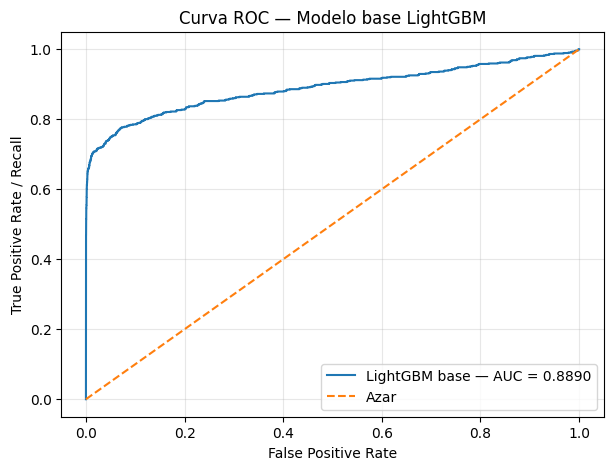

In [11]:
fpr, tpr, _ = roc_curve(y_test, test_proba)
auc_value = roc_auc_score(y_test, test_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"LightGBM base — AUC = {auc_value:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("Curva ROC — Modelo base LightGBM")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

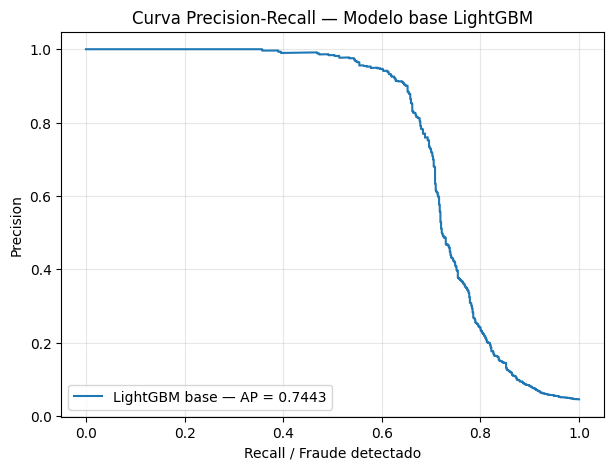

In [12]:
prec_curve, rec_curve, _ = precision_recall_curve(y_test, test_proba)
ap_value = average_precision_score(y_test, test_proba)

plt.figure(figsize=(7, 5))
plt.plot(rec_curve, prec_curve, label=f"LightGBM base — AP = {ap_value:.4f}")
plt.xlabel("Recall / Fraude detectado")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall — Modelo base LightGBM")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 11. Importancia de variables

Esta tabla permite revisar qué variables está utilizando más el modelo base. Es útil para validar si el modelo está aprovechando señales relacionadas con monto, distancia, tiempo, canal o comercio.

In [13]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": base_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.to_csv(RESULTS_DIR / "baseline_feature_importance.csv", index=False)
feature_importance.head(25)

,feature,importance
14,DE18_merchant_category_code,275
44,amount_baseline_ratio,192
16,DE22_pos_entry_mode,80
36,distance_from_home_km,79
1,channel,72
42,is_hotel,65
43,amount_vs_baseline,59
5,DE4_amount_transaction,48
6,DE6_amount_cardholder_billing,42
12,DE14_expiration_date,40


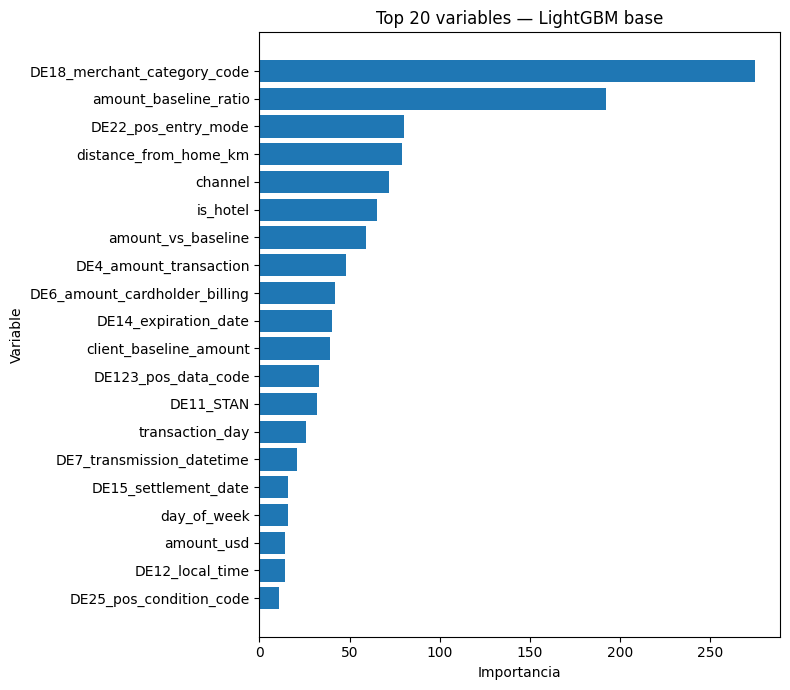

In [14]:
top_n = 20
plot_df = feature_importance.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 7))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title(f"Top {top_n} variables — LightGBM base")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## 12. Guardar predicciones de junio

Se guarda un archivo con la probabilidad estimada de fraude y las predicciones binarias según el umbral seleccionado por F1. Este archivo sirve para auditoría y para comparar contra los modelos con métricas personalizadas.

In [15]:
predictions_june = pd.DataFrame({
    "transaction_id": test_df["transaction_id"].values if "transaction_id" in test_df.columns else np.arange(len(test_df)),
    "is_fraud_real": y_test.values.astype(bool),
    "fraud_probability_baseline": test_proba,
    "pred_baseline_best_f1": y_pred_selected.astype(bool),
    "selected_threshold": selected_threshold
})

predictions_june.to_csv(RESULTS_DIR / "baseline_predictions_june.csv", index=False)
predictions_june.head()

,transaction_id,is_fraud_real,fraud_probability_baseline,pred_baseline_best_f1,selected_threshold
0,efdf6b17-f65a-4b40-aee6-1bee761ac9a0,False,0.160228,False,0.866945
1,8d77d053-a4b2-4049-b793-474a294decd4,False,0.140867,False,0.866945
2,e1238766-9f81-45fa-90a0-a3d9afa24734,True,0.981381,True,0.866945
3,140e5d88-3560-4485-8474-9bfc3085d780,False,0.123941,False,0.866945
4,115f95f5-ad88-4ec1-84df-613017dc75df,False,0.171899,False,0.866945


## 13. Conclusión para el informe

El modelo base con LightGBM establece una primera referencia cuantitativa para la detección de fraude. La comparación entre umbrales muestra que el rendimiento no debe analizarse solo con AUC-ROC, ya que en un problema desbalanceado también importa cuántos fraudes reales se detectan y cuántas alertas falsas se generan.

En la siguiente etapa, las métricas personalizadas deberán compararse contra este baseline usando especialmente la razón de falsos positivos por fraude detectado y la proporción de falsos positivos dentro de las alertas generadas.